# <div style="background: linear-gradient(90deg, #3f0d12, #a71d31); padding: 16px 20px; border-radius: 12px; color: white;">
# CIC IIoT Dataset 2025: Attack Data Exploration
# </div>

<div style="margin-top: 12px; padding: 14px 18px; border-left: 6px solid #b91c1c; background: #fef2f2; border-radius: 8px;">
<b>Research question:</b> Does using a knowledge graph with a graph neural network (GNN) detect attacks on IoT better than using normal models that do not use graphs?<br>
<b>Purpose of this notebook:</b> inspect the attack-only file and understand whether it provides meaningful malicious patterns for future comparison against benign traffic.
</div>

## Why this notebook matters

This file contains only attack traffic. That means it is useful for understanding malicious behavior, but it is not enough by itself to train a supervised benign-vs-attack classifier. Its strongest value is to help us identify attack characteristics that can later be compared against the benign baseline notebook.


In [12]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)
plt.style.use('ggplot')

DATASET_PATH = Path(r"/Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch/IoT_dataset/CIC IIoT dataset 2025/Attack_samples/attack_samples_1sec.csv")
DATASET_PATH


PosixPath('/Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch/IoT_dataset/CIC IIoT dataset 2025/Attack_samples/attack_samples_1sec.csv')

## <div style="color:#b91c1c;">1. Load the attack dataset</div>

We first load the file and convert the timestamps. Each row appears to summarize one second of traffic, similar to the benign dataset.


In [13]:
df = pd.read_csv(DATASET_PATH)

df['timestamp_start'] = pd.to_datetime(df['timestamp_start'], utc=True)
df['timestamp_end'] = pd.to_datetime(df['timestamp_end'], utc=True)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head(5)


Rows: 90,391
Columns: 94


,device_name,device_mac,label_full,label1,label2,label3,label4,timestamp,timestamp_start,timestamp_end,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types,log_data-types_count,log_interval-messages,log_messages_count,network_fragmentation-score,network_fragmented-packets,network_header-length_avg,network_header-length_max,network_header-length_min,network_header-length_std_deviation,network_interval-packets,network_ip-flags_avg,network_ip-flags_max,network_ip-flags_min,network_ip-flags_std_deviation,network_ip-length_avg,network_ip-length_max,network_ip-length_min,network_ip-length_std_deviation,network_ips_all,network_ips_all_count,network_ips_dst,network_ips_dst_count,network_ips_src,network_ips_src_count,network_macs_all,network_macs_all_count,network_macs_dst,network_macs_dst_count,network_macs_src,network_macs_src_count,network_mss_avg,network_mss_max,network_mss_min,network_mss_std_deviation,network_packet-size_avg,network_packet-size_max,network_packet-size_min,network_packet-size_std_deviation,network_packets_all_count,network_packets_dst_count,network_packets_src_count,network_payload-length_avg,network_payload-length_max,network_payload-length_min,network_payload-length_std_deviation,network_ports_all,network_ports_all_count,network_ports_dst,network_ports_dst_count,network_ports_src,network_ports_src_count,network_protocols_all,network_protocols_all_count,network_protocols_dst,network_protocols_dst_count,network_protocols_src,network_protocols_src_count,network_tcp-flags-ack_count,network_tcp-flags-fin_count,network_tcp-flags-psh_count,network_tcp-flags-rst_count,network_tcp-flags-syn_count,network_tcp-flags-urg_count,network_tcp-flags_avg,network_tcp-flags_max,network_tcp-flags_min,network_tcp-flags_std_deviation,network_time-delta_avg,network_time-delta_max,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
0,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:10.709000Z_2025-01-23T15:31:1...,2025-01-23 15:31:10.709000+00:00,2025-01-23 15:31:11.709000+00:00,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,[],0,[],0,[],0,[],0,[],0,[],0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,[],0,[],0,[],0,[],0,[],0,[],0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:11.709000Z_2025-01-23T15:31:1...,2025-01-23 15:31:11.709000+00:00,2025-01-23 15:31:12.709000+00:00,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,[],0,[],0,[],0,[],0,[],0,[],0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,[],0,[],0,[],0,[],0,[],0,[],0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:12.709000Z_2025-01-23T15:31:1...,2025-01-23 15:31:12.709000+00:00,2025-01-23 15:31:13.709000+00:00,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,[],0,[],0,[],0,[],0,[],0,[],0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,[],0,[],0,[],0,[],0,[],0,[],0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:13.709000Z_2025-01-23T15:31:1...,2025-01-23 15:31:13.709000+00:00,2025-01-23 15:31:14.709000+00:00,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,[],0,[],0,[],0,[],0,[],0,[],0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0.0,

## <div style="color:#b91c1c;">2. Quick profile of the dataset</div>

This section answers the first practical questions:

- Is the file truly attack-only?
- What attack families are present?
- Which devices are targeted?
- How long is the capture?
- Is the dataset large and diverse enough to support the research?


In [14]:
profile = {
    'rows': df.shape[0],
    'columns': df.shape[1],
    'unique_devices': df['device_name'].nunique(),
    'unique_device_macs': df['device_mac'].nunique(),
    'unique_label_full': df['label_full'].nunique(),
    'unique_label1': df['label1'].nunique(),
    'unique_label2': df['label2'].nunique(),
    'unique_label3': df['label3'].nunique(),
    'time_start': df['timestamp_start'].min(),
    'time_end': df['timestamp_end'].max(),
    'duration_seconds': (df['timestamp_end'].max() - df['timestamp_start'].min()).total_seconds(),
}

pd.DataFrame(profile.items(), columns=['Metric', 'Value'])


,Metric,Value
0,rows,90391
1,columns,94
2,unique_devices,38
3,unique_device_macs,38
4,unique_label_full,936
5,unique_label1,1
6,unique_label2,7
7,unique_label3,60
8,time_start,2025-01-15 13:04:54.353000+00:00
9,time_end,2025-06-12 19:11:54.585000+00:00


In [15]:
for col in ['label_full', 'label1', 'label2', 'label3', 'label4', 'device_name']:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False).to_string())



Value counts for label_full:
label_full
attack_recon_os-scan_whole-network                                     2260
attack_recon_host-disc-tcp-ack-ping_whole-network                      2239
attack_recon_vuln-scan_whole-network                                   2236
attack_recon_host-disc-tcp-syn-ping_whole-network                      2224
attack_recon_port-scan_whole-network                                   2215
attack_recon_host-disc-tcp-syn-stealth_whole-network                   2210
attack_recon_ping-sweep_whole-network                                  2210
attack_recon_host-disc-arp-ping_whole-network                          2203
attack_recon_host-disc-udp-ping_whole-network                          2186
attack_web_command-injection_edge1                                      996
attack_web_sql-injection-blind_edge1                                    990
attack_malware_mirai-udp-flood_steam-sensor--edge1,mqtt-broker          730
attack_malware_mirai-syn-flood_ap--edge1,mqtt-b

### Interpretation

<div style="padding: 12px 16px; background: #fff7ed; border-radius: 8px; border: 1px solid #fdba74;">
This file contains only <b>attack</b> observations. In this CIC IIoT 2025 extract, the attack labels cover <b>multiple high-level families</b> (e.g., <code>recon</code>, <code>dos</code>, <code>ddos</code>, <code>mitm</code>, <code>malware</code>, <code>web</code>, <code>bruteforce</code>) with many subtypes (e.g., scans, spoofing, Mirai floods, and protocol-specific flooding variants). That is useful because it gives us a substantial malicious dataset for comparing attack behavior against the benign baseline.
</div>

Important observations:

- The dataset is large enough to support meaningful supervised learning and comparison with the benign dataset.
- The attack distribution is <b>not uniform</b>: some families/subtypes appear much more frequently than others, so per-family performance may differ from the overall binary (attack vs benign) score.
- For the baseline part of this project we collapse all families into a single <b>attack</b> label; later, we can extend the study to <b>multi-class</b> (by <code>label2</code>/<code>label3</code>) or per-family analysis.

So this file is a strong starting point for binary intrusion detection experiments, while still being limited to the attack families represented in this dataset extract (which may not cover every real-world IIoT attack type).


## <div style="color:#b91c1c;">3. Data quality and structural checks</div>

Before drawing conclusions, we need to know whether the file has empty windows, constant variables, or other issues that could distort the analysis.


In [16]:
numeric_df = df.select_dtypes(include='number')
null_summary = df.isna().sum().sort_values(ascending=False)
duplicate_rows = df.duplicated().sum()
constant_numeric = [c for c in numeric_df.columns if numeric_df[c].nunique(dropna=False) == 1]
zero_rate = (numeric_df == 0).mean().sort_values(ascending=False)
all_zero_rows = (numeric_df.sum(axis=1) == 0).sum()

print(f"Duplicate rows: {duplicate_rows}")
print(f"Columns with missing values: {(null_summary > 0).sum()}")
print(f"Rows with all numeric values equal to zero: {all_zero_rows}")
print("\nConstant numeric columns:")
print(constant_numeric)
print("\nHighest zero-rate numeric columns:")
print(zero_rate.head(20).to_string())


Duplicate rows: 0
Columns with missing values: 0
Rows with all numeric values equal to zero: 9674

Constant numeric columns:
[]

Highest zero-rate numeric columns:
network_header-length_std_deviation    0.999358
network_tcp-flags-urg_count            0.994590
network_mss_std_deviation              0.988074
log_interval-messages                  0.986946
log_data-ranges_std_deviation          0.976358
network_ip-flags_min                   0.920667
network_fragmentation-score            0.906053
network_fragmented-packets             0.906053
network_tcp-flags-fin_count            0.890454
log_data-ranges_min                    0.862464
log_data-ranges_max                    0.861347
log_data-ranges_avg                    0.861347
network_payload-length_min             0.860528
log_messages_count                     0.844730
log_data-types_count                   0.844730
network_mss_avg                        0.604573
network_mss_min                        0.604573
network_mss_max     

### Interpretation

<div style="padding: 12px 16px; background: #fef2f2; border-radius: 8px; border: 1px solid #fca5a5;">
One important warning sign is that some attack windows are numerically all zero. That does not necessarily mean the labels are wrong, but it does mean we must be careful: some windows may represent preprocessing gaps, silent intervals, or attack windows with no captured features.
</div>

### What it actually means when attack rows look empty

If an attack row looks empty, it usually means that in that 1-second window the aggregated numeric features did not capture clear visible activity. In practice, that can happen for several reasons:

- the attack may not have been equally intense during every second,
- the attack may have had short pauses or weak intervals,
- the aggregation window may have captured a transition period rather than an active burst,
- the attack label may apply to a broader time segment even though one specific second contains little measurable activity,
- or the selected numeric features may not be rich enough to reflect what was happening in that window.

So an empty-looking attack row does **not** always mean “this is not an attack.” It may mean “the attack is not strongly visible in these particular aggregated features during this specific second.”

### Why this matters for interpretation

If too many attack rows look empty, then the distinction between benign and attack becomes less clean in a purely tabular setting. A classifier may struggle because it expects attack rows to look obviously abnormal, but some of them may look almost like inactivity.

That can lead to several problems:

- the model may confuse weak attack windows with benign windows,
- the model may over-rely on a few extremely strong attack windows,
- the model may learn dataset artifacts instead of true malicious behavior,
- and performance may look unstable depending on how the train/test split captures those sparse rows.

### What this means for your project specifically

This is actually an important research insight, not just a data quality issue.

- For **classical tabular models**, sparse attack windows can weaken the signal because the model sees each row mostly as an isolated feature vector.
- For **anomaly detection**, sparse rows may still be meaningful if they occur in suspicious temporal context.
- For **graph-based modeling**, these rows may become more informative because even if one window has weak numeric intensity, the surrounding relationships among devices, ports, protocols, or time windows may still reveal malicious structure.

That is one of the reasons your graph-based research question is valuable. A GNN may eventually help when individual rows are not always strong enough on their own.

### Practical takeaway

When you see empty-looking attack rows, interpret them as a warning that:

1. not every attack second is equally informative,
2. attack behavior may be temporally uneven,
3. feature engineering matters,
4. and relational or temporal context may be necessary to improve detection.

Constant features still will not help classification, and sparse attack windows make purely tabular supervised modeling harder, but they may be very relevant when we move toward anomaly detection or graph-based analysis.


## <div style="color:#b91c1c;">4. Key descriptive statistics</div>

These features summarize attack intensity, communication diversity, and packet-level behavior.


In [17]:
key_features = [
    'network_packets_all_count',
    'network_packets_src_count',
    'network_packets_dst_count',
    'network_ips_all_count',
    'network_ports_all_count',
    'network_protocols_all_count',
    'network_packet-size_avg',
    'network_payload-length_avg',
    'network_ttl_avg',
    'network_time-delta_avg'
]

df[key_features].describe().T


,count,mean,std,min,25%,50%,75%,max
network_packets_all_count,90391.0,18029.761945,35495.928945,0.000000e+00,12.000000,202.000000,13569.500000,149006.000000
network_packets_src_count,90391.0,1181.193614,4918.474514,0.000000e+00,1.000000,18.000000,218.000000,67113.000000
network_packets_dst_count,90391.0,16848.568331,34491.204375,0.000000e+00,6.000000,80.000000,12366.000000,149006.000000
network_ips_all_count,90391.0,8.872598,27.488686,0.000000e+00,2.000000,2.000000,6.000000,238.000000
network_ports_all_count,90391.0,6060.964532,14657.690353,0.000000e+00,2.000000,26.000000,1002.000000,65916.000000
network_protocols_all_count,90391.0,2.003595,1.478907,0.000000e+00,1.000000,2.000000,3.000000,20.000000
network_packet-size_avg,90391.0,170.980627,288.857609,0.000000e+00,60.000000,60.034320,91.862308,1487.073986
network_payload-length_avg,90391.0,169.905808,424.553213,0.000000e+00,0.000000,0.082192,38.000000,1613.825217
network_ttl_avg,90391.0,83.046881,53.638122,0.000000e+00,63.666667,64.004252,142.470588,255.000000
network_time-delta_avg,90391.0,0.003359,0.008961,-1.800000e-07,0.000014,0.000106,0.001974,0.310541


### Interpretation

A few patterns stand out:

- Packet counts are extremely large compared with the benign dataset, which is consistent with DDoS-style flooding.
- The median attack traffic is already very high in several variables, meaning the high activity is not just a few outliers.
- Average payload length is often zero, which suggests some of these floods are dominated by control or header-heavy traffic rather than rich payload exchange.
- The number of ports observed is very large, which may indicate broad scanning or high-volume port-level activity depending on the attack variant.

This is a strong sign that the attack file contains meaningful traffic intensity patterns, even if some windows are sparse.


## <div style="color:#b91c1c;">5. Attack behavior by device and attack subtype</div>

Here we compare how traffic intensity changes across targeted devices and attack labels.


In [18]:
device_summary = (
    df.groupby('device_name')
      .agg(
          rows=('device_name', 'size'),
          mean_packets=('network_packets_all_count', 'mean'),
          median_packets=('network_packets_all_count', 'median'),
          mean_ports=('network_ports_all_count', 'mean'),
          mean_ips=('network_ips_all_count', 'mean')
      )
      .sort_values('mean_packets', ascending=False)
)

label_summary = (
    df.groupby('label3')
      .agg(
          rows=('label3', 'size'),
          mean_packets=('network_packets_all_count', 'mean'),
          median_packets=('network_packets_all_count', 'median'),
          mean_ports=('network_ports_all_count', 'mean'),
          mean_ips=('network_ips_all_count', 'mean')
      )
      .sort_values('mean_packets', ascending=False)
)

print('By device')
display(device_summary)
print('\nBy attack subtype')
display(label_summary)


By device


,rows,mean_packets,median_packets,mean_ports,mean_ips
device_name,,,,,
switch,2440,25438.231148,10589.5,9408.243443,2.631557
dekco-camera,2413,24716.383755,4295.0,8661.403232,2.777041
router,4053,24580.921046,4056.0,6368.480385,10.184801
blurams-camera,2431,24556.552448,6840.0,8560.503085,3.213492
myq-camera,2476,23479.055331,4183.0,7881.307754,2.765347
proximity-collision-sensor,2545,23038.249509,264.0,8191.814931,2.680550
water-sensor,2565,22714.426511,499.0,8393.264327,3.215205
rfid-sensor,2534,22586.504341,376.5,8101.833860,2.666930
flame-sensor,2540,22572.727953,392.5,8242.953543,2.660630



By attack subtype


,rows,mean_packets,median_packets,mean_ports,mean_ips
label3,,,,,
udp-flood-port-1883,922,123634.911063,148378.5,439.636659,4.828633
udp-flood-port-80,676,116838.587278,148442.5,507.871302,5.181953
rst-fin-flood-port-80,983,92985.354018,147155.0,46243.775178,5.066124
udp-flood,1722,77141.722997,85443.0,156.501161,2.842625
rst-fin-flood-port-1883,2214,73574.882565,44700.5,43250.130533,3.957091
syn-flood-port-22,64,72460.218750,78999.0,24217.031250,6.765625
push-ack-flood-port-80,1347,59174.611730,32452.0,31346.152190,4.368968
syn-flood-port-80,1349,59137.958488,48461.0,31720.373610,4.440326
push-ack-flood-port-1883,1844,56628.799349,27255.0,34236.519523,4.444143


### Interpretation

These tables summarize how attack behavior changes across **devices** (`device_name`) and across **attack subtypes** (`label3`). Each row is an aggregate over many **1-second windows**, and the `rows` column tells you how many windows contribute to that summary.

#### How to interpret the columns

- **`rows`**: sample size (number of 1-second attack windows for that device or subtype). Interpret averages more cautiously when `rows` is small.
- **`mean_packets`**: the **average** number of packets per 1-second window (`network_packets_all_count`).
  - High values mean the attack is **packet-volume heavy on average**.
  - The mean is sensitive to rare extreme bursts (a few very large seconds can pull the mean upward).
- **`median_packets`**: the **typical** number of packets per 1-second window (the 50th percentile).
  - If `median_packets` is also high, the traffic is **consistently intense**, not just occasional spikes.
  - If `mean_packets` is much larger than `median_packets` (especially if the median is near 0), the subtype/device is **bursty/sparse**: many seconds are quiet, but some seconds have very large spikes.
- **`mean_ports`**: the average value of `network_ports_all_count`. In practice you can treat this as a proxy for **port-level activity / port diversity / connection churn** in the window.
  - Higher values often align with behaviors like **scanning** or attacks that touch many services/ports.
  - Lower values are consistent with attacks that focus on a **single service/port** (e.g., a fixed target port).
- **`mean_ips`**: the average value of `network_ips_all_count`, which you can interpret as **IP diversity** in the window (how many distinct endpoints show up).
  - Higher values can suggest **distributed sources** (bot-like behavior) or **host discovery** behavior touching many endpoints.
  - Lower values suggest a more **focused** communication pattern (fewer endpoints involved).

#### What these summaries suggest in this file

- Many flood-style subtypes have extremely large `mean_packets` and also large `median_packets`, which indicates **sustained high-rate behavior** (not only a few outliers).
- Recon-style subtypes (e.g., OS/port scans and host discovery) tend to have **much smaller packet volumes**, but may show relatively higher **port activity** compared to their packet counts. This is consistent with probing behavior: fewer packets per target, spread across many ports.
- Some devices show `median_packets` close to **zero** while still having a non-trivial `mean_packets` (several `plug-*` device groups do this). This is the signature of **sparse attack windows**: many seconds contain little measurable activity, while a smaller number of seconds contain very strong bursts that raise the mean.

Later, when we build models, these differences matter: a single global threshold can miss sparse/bursty attacks, and subtype/device variation can motivate **device-aware evaluation** or an extension to **multi-class labels** (using `label2`/`label3`) rather than only binary attack vs benign.


## <div style="color:#b91c1c;">6. Visual exploration</div>

The next charts help us see whether the attack traffic is concentrated, bursty, sparse, or structurally different across subtypes.


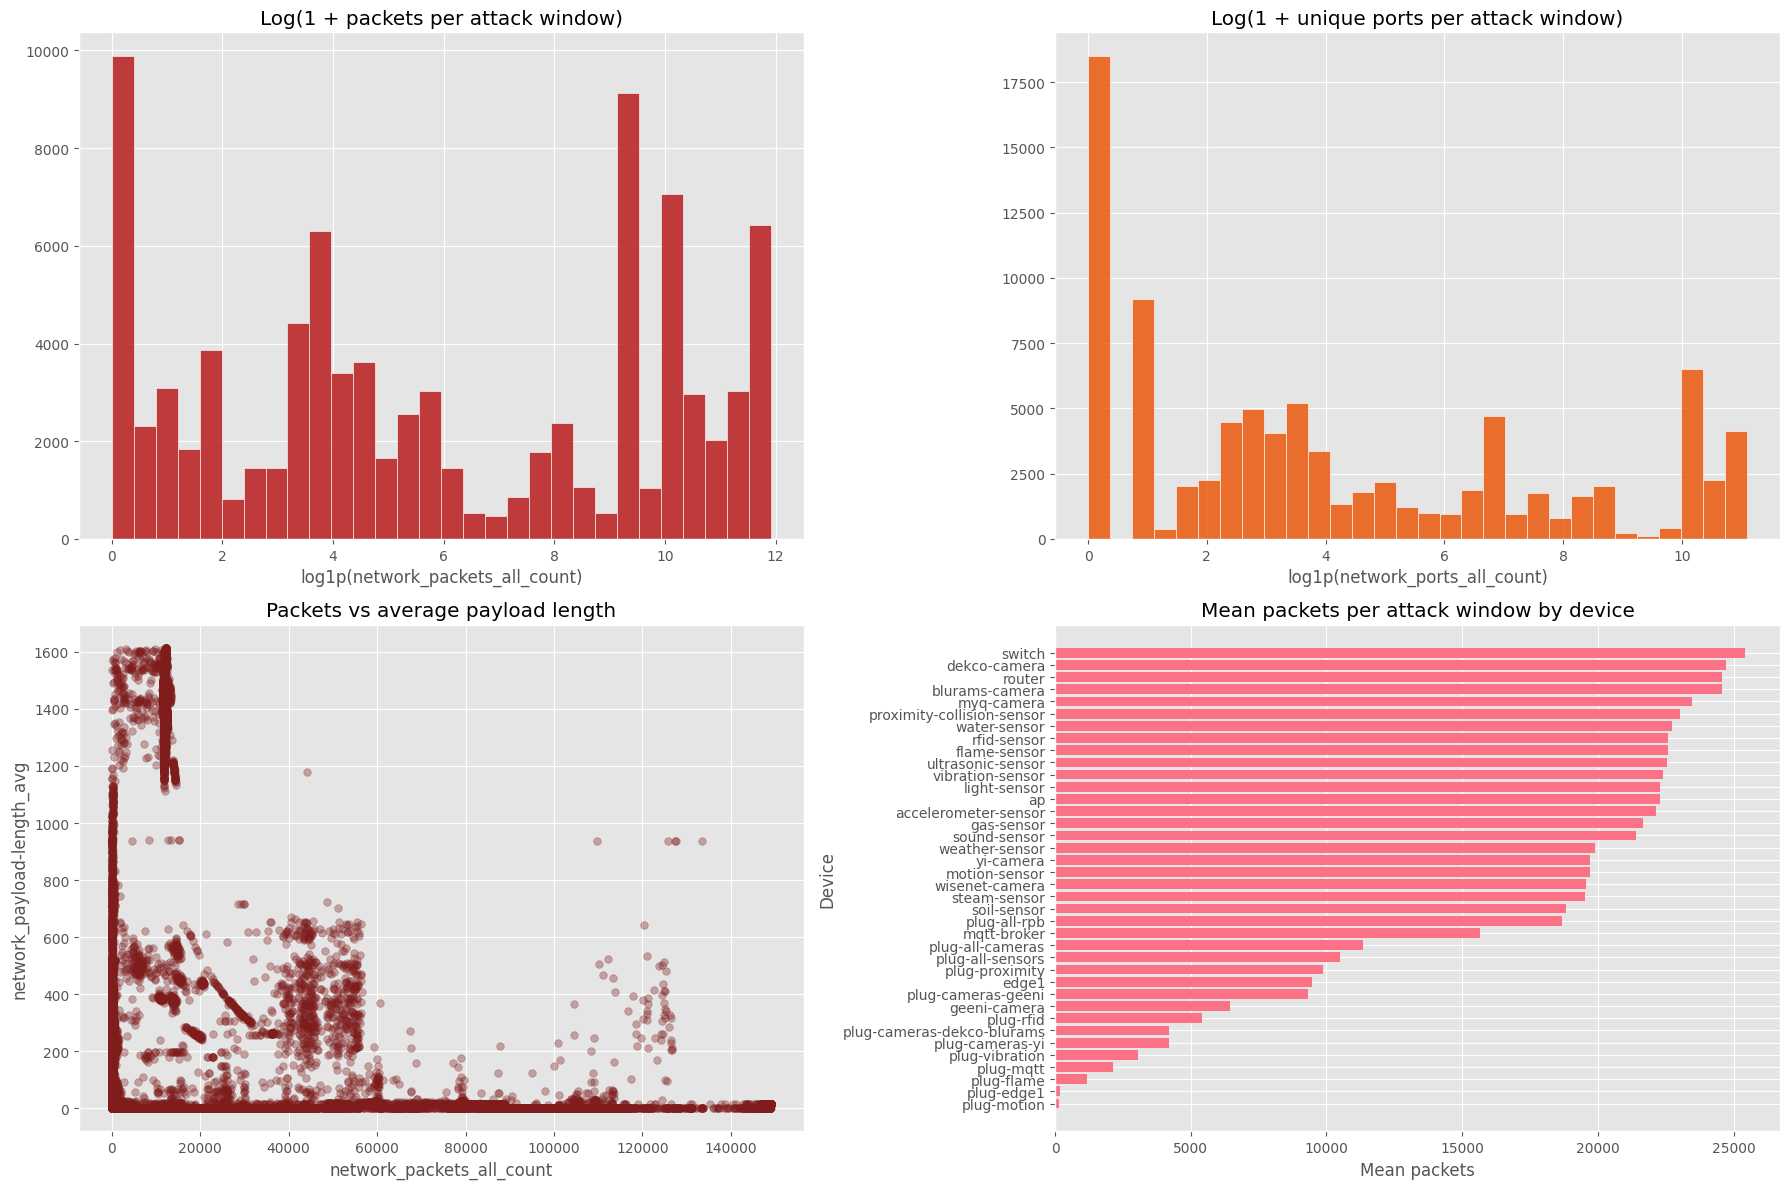

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].hist(np.log1p(df['network_packets_all_count']), bins=30, color='#b91c1c', alpha=0.85, edgecolor='white')
axes[0, 0].set_title('Log(1 + packets per attack window)')
axes[0, 0].set_xlabel('log1p(network_packets_all_count)')

axes[0, 1].hist(np.log1p(df['network_ports_all_count']), bins=30, color='#ea580c', alpha=0.85, edgecolor='white')
axes[0, 1].set_title('Log(1 + unique ports per attack window)')
axes[0, 1].set_xlabel('log1p(network_ports_all_count)')

axes[1, 0].scatter(df['network_packets_all_count'], df['network_payload-length_avg'], alpha=0.35, s=30, color='#7f1d1d')
axes[1, 0].set_title('Packets vs average payload length')
axes[1, 0].set_xlabel('network_packets_all_count')
axes[1, 0].set_ylabel('network_payload-length_avg')

device_plot = device_summary.reset_index().sort_values('mean_packets')
axes[1, 1].barh(device_plot['device_name'], device_plot['mean_packets'], color='#fb7185')
axes[1, 1].set_title('Mean packets per attack window by device')
axes[1, 1].set_xlabel('Mean packets')
axes[1, 1].set_ylabel('Device')

plt.tight_layout()
plt.show()


### How to interpret these plots (attack traffic)

<div style="padding: 12px 16px; background: #fef2f2; border-radius: 8px; border: 1px solid #fca5a5;">
These four panels summarize what <b>malicious (attack)</b> activity looks like when it is aggregated into <b>1-second windows</b>. The goal is not to identify the exact attack subtype here, but to understand whether attacks exhibit distinctive <b>volume</b>, <b>diversity</b>, and <b>packet-vs-payload</b> patterns that can later separate them from benign traffic.
</div>

A note about the axis transform in the two histograms:

- We plot <code>log(1 + x)</code> (<code>log1p</code>) because packet and port counts can span multiple orders of magnitude and may include zeros.
- The transform compresses extreme values so the distribution shape is readable while still preserving ordering.

#### Panel (a): Histogram of <code>log(1 + packets)</code>

- If most values are far from 0 (shifted to the right), then many windows contain <b>high packet volume</b>, which is consistent with flooding-style behavior.
- If the histogram has both a high-mass region and a long tail, the attack is <b>bursty</b>: many windows are moderate, while some windows spike extremely high.
- When you compare against benign later, pay attention to whether attack traffic is not only higher in maximums, but also higher in the <b>typical</b> region (median-like behavior). That distinction matters for recall: a model can miss attacks if only a small fraction of windows are extreme.

#### Panel (b): Histogram of <code>log(1 + unique ports)</code>

- Higher values mean the window touches <b>more distinct ports</b> (port diversity / connection churn).
- Very high port diversity can indicate behaviors like <b>scanning</b> or rapid connection attempts across services.
- Lower port diversity can still be malicious if the attack is targeted to a specific service/port (e.g., repeated flooding of one service).

#### Panel (c): Scatter of <code>packets</code> vs <code>average payload length</code>

- Each point is one 1-second attack window.
- A common attack signature (especially for floods) is <b>many packets with low average payload</b>. That means the traffic is dominated by transport/control behavior rather than content exchange.
- Do not over-interpret a single point: some attack windows can be sparse (near-zero activity) due to windowing effects or burst timing. The pattern to look for is the <b>concentration</b> of points at high packets with low payload, compared to benign.

#### Panel (d): Mean packets per attack window by device

- This shows that attack intensity can be <b>device-dependent</b>. Some devices experience consistently higher packet-volume windows than others in the same capture.
- This motivates checking whether results hold across devices (not driven by a single device).
- It also motivates being careful with <code>device_name</code> as a feature, because it can leak identity rather than behavior.

#### Takeaway you can use in the paper (EDA)

Attack traffic in 1-second windows often shows distinctive patterns in <b>packet volume</b>, <b>port diversity</b>, and <b>packet-vs-payload structure</b>. These plots help us form hypotheses about what differentiates malicious behavior (e.g., sustained or bursty high packet rates, scanning-like port diversity, and header-heavy floods) before we move into supervised baselines and graph-based designs.


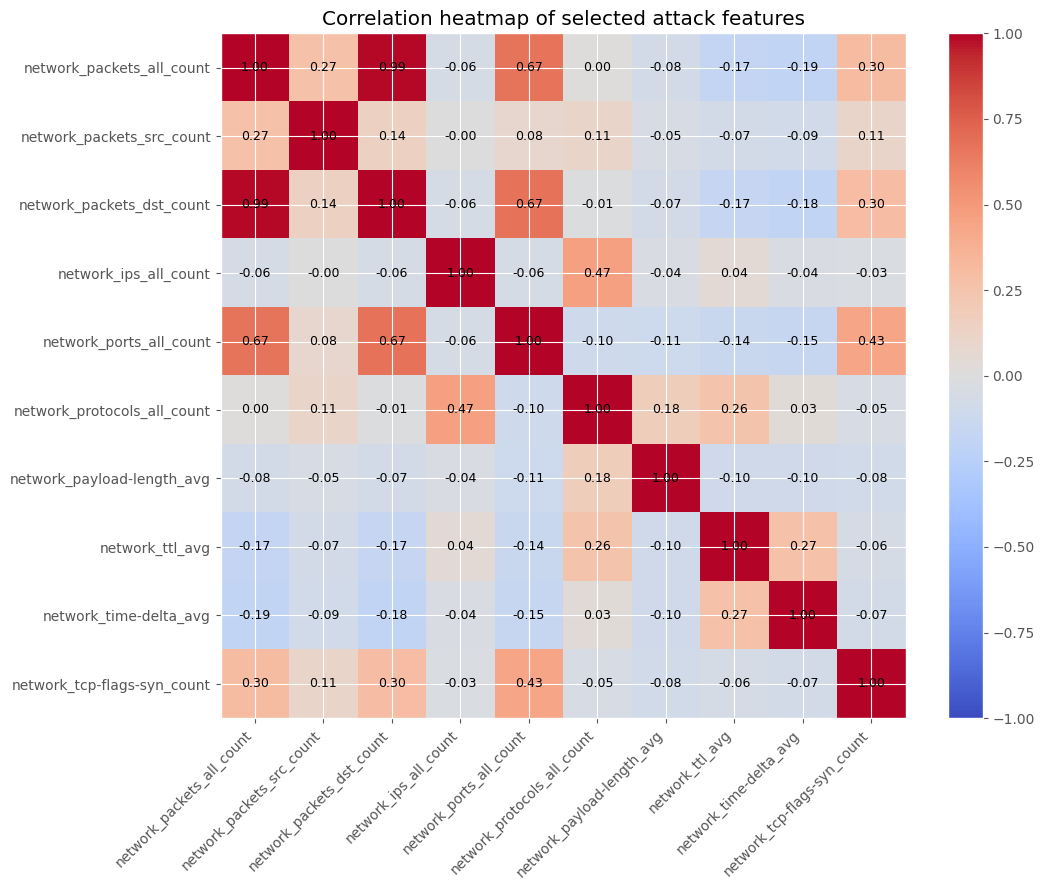

In [20]:
corr_features = [
    'network_packets_all_count',
    'network_packets_src_count',
    'network_packets_dst_count',
    'network_ips_all_count',
    'network_ports_all_count',
    'network_protocols_all_count',
    'network_payload-length_avg',
    'network_ttl_avg',
    'network_time-delta_avg',
    'network_tcp-flags-syn_count'
]

corr = df[corr_features].corr()
fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title('Correlation heatmap of selected attack features')

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black', fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


### Correlation interpretation (attack traffic)

The heatmap shows which attack features tend to rise and fall together across 1-second windows. This is useful because many attacks do not change a single variable in isolation; they change a <b>pattern of variables</b> simultaneously.

### How to read the values and colors

- Correlation close to <code>+1</code>: the two features increase together strongly.
- Correlation close to <code>-1</code>: one tends to increase when the other decreases.
- Correlation close to <code>0</code>: little linear relationship.

Color intuition (with <code>coolwarm</code>):

- Stronger <b>red</b> means stronger positive correlation.
- Stronger <b>blue</b> means stronger negative correlation.
- Pale/neutral colors mean weak relationship.

### What to look for in attack data

- **Volume cluster:** strong positive correlations among packet-count features (e.g., total/src/dst packets) are expected in flood-like activity because multiple volume indicators rise together.
- **Diversity coupling:** if <code>network_ports_all_count</code> and <code>network_ips_all_count</code> correlate with packet volume, the capture may contain attacks that are not only high-rate, but also <b>broad</b> (touching many endpoints/ports).
- **Protocol/flag alignment:** if a TCP flag count (e.g., SYN) correlates with packet volume, that supports a mechanistic interpretation (e.g., connection-attempt bursts).

### Why this matters for the project

- Classical models can exploit these numeric relationships directly.
- Graph-based methods can represent a similar idea structurally: nodes/edges corresponding to device-state patterns that co-occur under attack.
- In the paper, one strong point to make is that attacks can appear as a <b>relationship change</b> (for example, packet volume increases while payload remains low), not just a magnitude change.


## <div style="color:#b91c1c;">7. Temporal behavior</div>

Because the file is short in duration, the time-series here should be read as an attack snapshot rather than a long behavioral history.


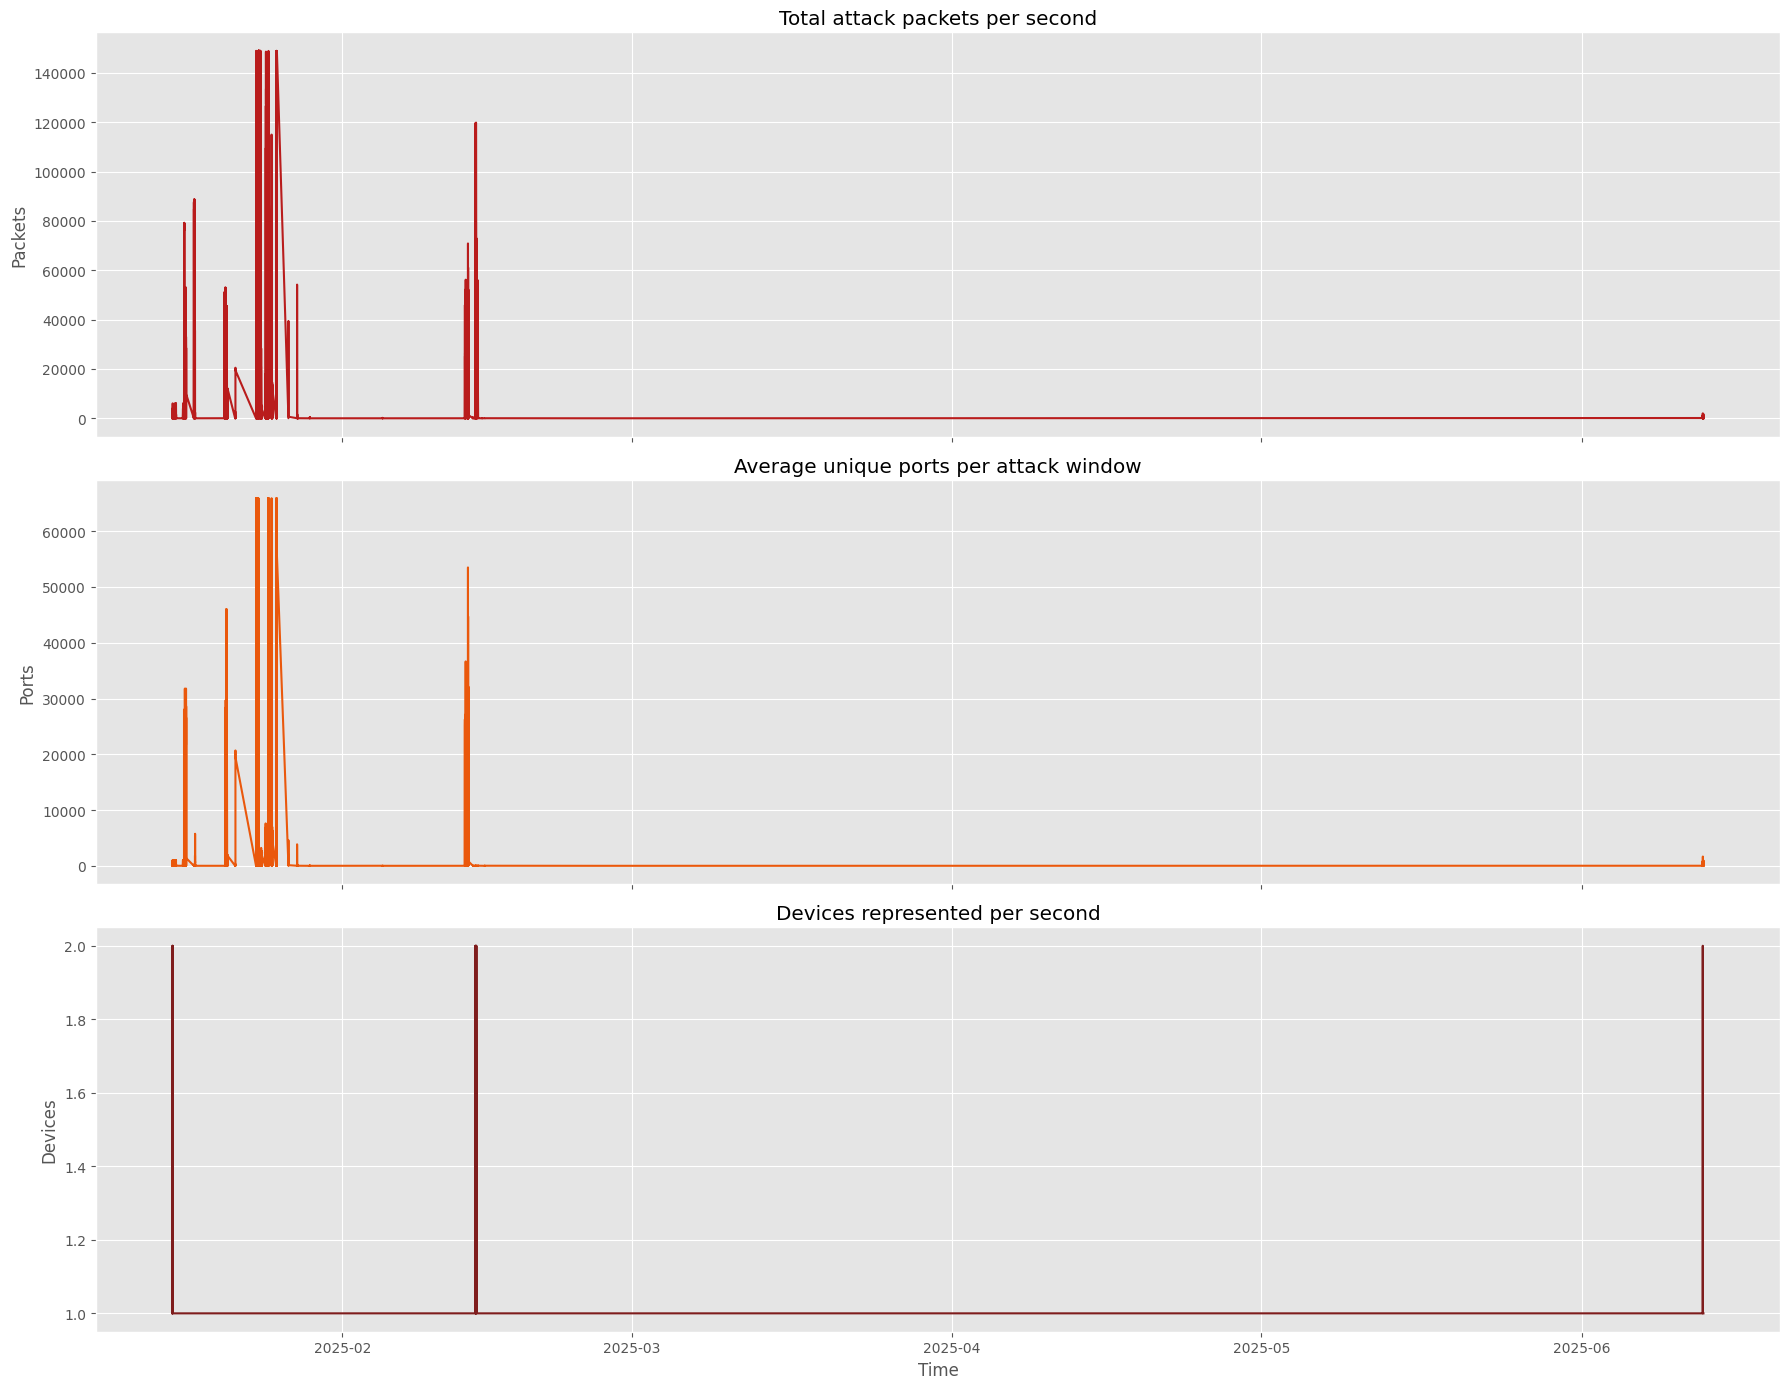

In [21]:
traffic_over_time = (
    df.groupby('timestamp_start')
      .agg(
          total_packets=('network_packets_all_count', 'sum'),
          avg_ports=('network_ports_all_count', 'mean'),
          active_devices=('device_name', lambda s: s.nunique())
      )
      .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)

axes[0].plot(traffic_over_time['timestamp_start'], traffic_over_time['total_packets'], color='#b91c1c')
axes[0].set_title('Total attack packets per second')
axes[0].set_ylabel('Packets')

axes[1].plot(traffic_over_time['timestamp_start'], traffic_over_time['avg_ports'], color='#ea580c')
axes[1].set_title('Average unique ports per attack window')
axes[1].set_ylabel('Ports')

axes[2].plot(traffic_over_time['timestamp_start'], traffic_over_time['active_devices'], color='#7f1d1d')
axes[2].set_title('Devices represented per second')
axes[2].set_ylabel('Devices')
axes[2].set_xlabel('Time')

plt.tight_layout()
plt.show()


### Interpretation (temporal shape of the attack capture)

These time-series plots summarize the <b>shape</b> of malicious activity over the capture period. Because the data is aggregated into 1-second windows, the most important question is whether the attack is <b>sustained</b> or <b>bursty</b>.

- If **total packets** stays elevated for long stretches, the attack is more consistent with a <b>sustained flood</b>. If it shows sharp spikes separated by quiet intervals, it indicates <b>bursty or intermittent</b> attack activity.
- If **average unique ports** changes substantially over time, it suggests the attack strategy shifts (for example, alternating between targeted flooding vs broader probing/scanning-like behavior).
- If **active devices** changes over time, the file may include multiple segments where different device groups are being observed or attacked, rather than one homogeneous episode.

When you compare against benign traffic later, this temporal shape is often one of the clearest differences: benign windows can burst, but they typically do not remain in a high-intensity regime for long continuous periods across many seconds.


## <div style="color:#b91c1c;">8. Why this file matters for graph construction</div>

Even though this file is attack-only, it still helps define how malicious relationships might look in a graph.


In [22]:
graph_candidates = pd.DataFrame({
    'Graph role': [
        'Target device node',
        'IP node',
        'Port node',
        'Protocol node',
        'Attack event node',
        'Edge attributes'
    ],
    'Candidate columns': [
        'device_name, device_mac',
        'network_ips_all, network_ips_src, network_ips_dst',
        'network_ports_all, network_ports_src, network_ports_dst',
        'network_protocols_all, network_protocols_src, network_protocols_dst',
        'timestamp_start, label3, label4',
        'packet counts, payload length, TTL, TCP flags'
    ],
    'Why useful': [
        'Represents the attacked IoT endpoint',
        'Shows who participates in malicious communication',
        'Shows targeted or active services',
        'Shows transport behavior',
        'Preserves attack subtype and time context',
        'Quantifies attack intensity on graph edges'
    ]
})

graph_candidates


,Graph role,Candidate columns,Why useful
0,Target device node,"device_name, device_mac",Represents the attacked IoT endpoint
1,IP node,"network_ips_all, network_ips_src, network_ips_dst",Shows who participates in malicious communication
2,Port node,"network_ports_all, network_ports_src, network_...",Shows targeted or active services
3,Protocol node,"network_protocols_all, network_protocols_src, ...",Shows transport behavior
4,Attack event node,"timestamp_start, label3, label4",Preserves attack subtype and time context
5,Edge attributes,"packet counts, payload length, TTL, TCP flags",Quantifies attack intensity on graph edges


### Graph interpretation

For your research question, this is important because tabular models only see numbers per row, while a graph can preserve who is connected to whom, through which port or protocol, at what time, and under what attack subtype.

That is the conceptual bridge toward a future GNN experiment.


## <div style="color:#b91c1c;">9. Final evaluation: does this attack dataset serve the project?</div>

<div style="padding: 14px 18px; background: #f8fafc; border-radius: 8px; border-left: 6px solid #b91c1c;">
<b>Short answer:</b> Yes. This is now a substantial attack dataset that can support meaningful comparison against benign traffic, although it still should not be treated as a complete standalone benchmark for every kind of IoT attack.
</div>

### Strengths

- It contains real malicious labels, not benign traffic.
- It contains multiple attack families and many subtypes (via `label2` and `label3`), enabling both binary and per-family analysis.
- It includes attack subtype labels that may support later multiclass exploration.
- It is useful for comparing attack behavior against the benign baseline.

### Limitations

- Even with multiple device types present, some attack families/subtypes may be concentrated in particular devices, which can bias results if not checked.
- The attack families represented are limited to the scenarios captured in this extract; performance may differ on unseen attack types or other environments.
- Some windows may still be sparse or less informative, which can affect direct modeling in some cases.

### Best use of this file

- Explore attack behavior.
- Compare with the benign dataset.
- Prototype feature selection.
- Start defining malicious graph patterns.


## <div style="color:#b91c1c;">10. What should happen next?</div>

The best next step is to create a third notebook that combines the benign file and this attack file. That combined notebook will let us answer the research question more directly.

In that next notebook we should:

1. align the benign and attack datasets,
2. compare feature distributions side by side,
3. identify the variables that most separate benign from attack windows,
4. train baseline non-graph models,
5. prepare the graph representation for a later GNN comparison.
